In [1]:
#Importing all the libraries
using SpecialFunctions
using LinearAlgebra
using DataFrames
using StatsPlots
using ProgressMeter
using Plots.Measures
using CSV
using Combinatorics
using MultinomialSeries
using SparseArrays
using LoopVectorization, Tullio
#using Threads
theme(:dao)
ProgressMeter.ijulia_behavior(:clear)

function scurve(x)  #Function for an S shaped curve, used inside survival function
    return 1/(1 + exp(-11 * (x - 0.5)))
end

int(x) = floor(Int, round(x))

Threads.nthreads()

4

In [2]:
SHAPE = "linear" #Switch between 1 being dominant or recessive
DOMINANT = false #Shape of survival function


P = Dict{String,Any}(
    "pm" => 0.1,        #Proportion of 1 for male locus
    "pf" => 0.1,        #Proportion of 1 for female locus
    "B" => 20,          #Eggs laid by non defender females
    "c_f" => 0.0,       #Cost to defender females
    "c_m" => 0.5,       #Cost for defender males
    "u" => 0.1,         #Probability of female staying unmated
    "r" => 0.1          #Ratio of males in a female-male mating
    )

function s(d, use = "exp")      #Probability of survival given the proportion of defenders in the offsprings
    if use == "linear"
        return d * (0.9 - 0.1) + 0.1
    elseif use == "expinv"
        return ((exp(-d * 2.5) - exp(0))/(exp(-1 * 2.5) - exp(0))) * (0.9 - 0.1) + 0.1
    elseif use == "exp"
        return ((exp(2.5*d) - exp(0))/(exp(2.5) - exp(0))) * (0.9 - 0.1) + 0.1
    elseif use == "s"
        return 0.8/(1 + exp(-11*(d - 0.5))) + 0.1#((scurve(d) - scurve(0)) / (scurve(1) - scurve(0))) * (0.9 - 0.1) + 0.1
    elseif use == "relu"
        return minimum(0.9, maximum(0.1, d^1.5))
    end
end

s (generic function with 2 methods)

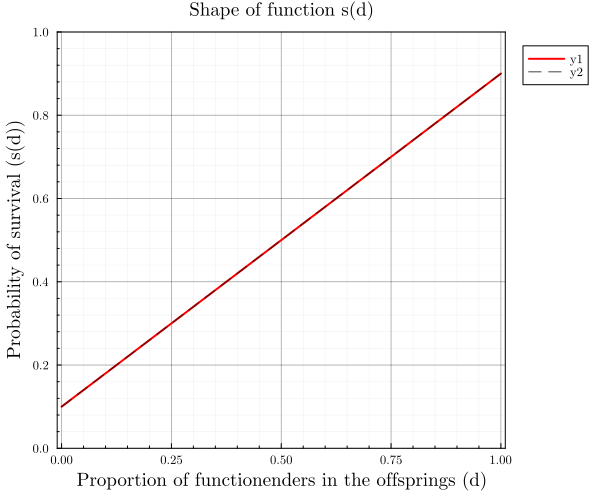

In [3]:
#Plotting the shape of survival function
d = range(0, stop=1, length=101)
plot(d, s.(d, SHAPE), lw = 2, lc=:red, size = (600,500))
plot!(d, range(0.1, stop=0.9, length=101), linestyle=:dash, color=:black, alpha=0.5, lw = 1.5)
xlims!(-0.01,1.01)
ylims!(0.0, 1)
xlabel!("Proportion of functionenders in the offsprings (d)")
ylabel!("Probability of survival (s(d))")
title!("Shape of function s(d)")

In [4]:
#Modular functions for different loops
function F(u, f, m, c, S) #Calculating the overall numberr of offsprings
    return u * f * m * c * S
end

function calc_surv(dist, C, r, def_index)
    prob = MultinomialSeries.multinomial(tuple(dist...)) * prod(r .^ dist) # Multinomial Probability of this brood composition
    return prob * s(any(isnan, sum(dist[begin:1:def_index])/C) ? 0 : sum(dist[begin:1:def_index])/C, SHAPE) #Multiplied by the survival chance
end

function calc_combinations(C, n_var, def_id, r)
    comb = [] #Initializing an empty array
    func = x -> x .* calc_surv(x, C, r, def_id) #Defining function to perform on the list of all combinations
    comb = vcat(sum(map(func,collect(Combinatorics.multiexponents(n_var, C))), dims = 1)...) #For each combination calculate the survival and multiply with each element of that combination and add all the results
    return comb
end

calc_combinations (generic function with 1 method)

In [5]:
# Calculating combinations for all the Reproduction types

P["comb_f01"] = calc_combinations(P["B"], 2, 1, [0.5, 0.5])

P["comb_f11"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 2, [0.25, 0.25, 0.25, 0.25]) : calc_combinations(P["B"], 4, 2, [0.25, 0.25, 0.25, 0.25])

P["comb_f21"] = calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [0.5, 0.5])


P["comb_f01m00"] = calc_combinations(P["B"], 4, 1, [0.5 * P["r"], 0.5 * P["r"], 0.5 * (1-P["r"]), 0.5 * (1-P["r"])])

P["comb_f02m00"] = calc_combinations(P["B"], 2, 1, [P["r"], (1-P["r"])])

P["comb_f10m00"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 1, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]]) : calc_combinations(P["B"], 4, 0, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]])

P["comb_f11m00"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 8, 4, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]]) : calc_combinations(P["B"], 8, 2, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]])

P["comb_f12m00"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 3, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5]) : calc_combinations(P["B"], 4, 2, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5])

P["comb_f20m00"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [1-P["r"], P["r"]]) : calc_combinations(int((1-P["c_f"])*P["B"]), 2, 0, [1-P["r"], P["r"]])

P["comb_f21m00"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 3, [P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5, 0.5 * P["r"]]) : calc_combinations(int((1-P["c_f"])*P["B"]), 4, 1, [P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5, 0.5 * P["r"]])

P["comb_f22m00"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 2, 2, [P["r"], 1-P["r"]]) : calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [P["r"], 1-P["r"]])


P["comb_f01m01"] = calc_combinations(P["B"], 4, 1, [0.5 * P["r"], 0.5 * P["r"], 0.5 * (1-P["r"]), 0.5 * (1-P["r"])])

P["comb_f02m01"] = calc_combinations(P["B"], 2, 1, [P["r"], (1-P["r"])])

P["comb_f10m01"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 1, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]]) : calc_combinations(P["B"], 4, 0, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]])

P["comb_f11m01"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 8, 4, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]]) : calc_combinations(P["B"], 8, 2, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]])

P["comb_f12m01"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 3, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5]) : calc_combinations(P["B"], 4, 2, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5])

P["comb_f20m01"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [1-P["r"], P["r"]]) : calc_combinations(int((1-P["c_f"])*P["B"]), 2, 0, [1-P["r"], P["r"]])

P["comb_f21m01"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 3, [P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5, 0.5 * P["r"]]) : calc_combinations(int((1-P["c_f"])*P["B"]), 4, 1, [P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5, 0.5 * P["r"]])

P["comb_f22m01"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 2, 2, [P["r"], 1-P["r"]]) : calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [P["r"], 1-P["r"]])


P["comb_f00m10"] = DOMINANT ? calc_combinations(P["B"], 2, 1, [1-P["r"], P["r"]]) : calc_combinations(P["B"], 2, 0, [1-P["r"], P["r"]])

P["comb_f01m10"] = DOMINANT ? calc_combinations(P["B"], 4, 3, [0.5 * P["r"], 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"]]) : calc_combinations(P["B"], 4, 1, [0.5 * P["r"], 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"]])

P["comb_f02m10"] = DOMINANT ? calc_combinations(P["B"], 2, 2, [P["r"], (1-P["r"])]) : calc_combinations(P["B"], 2, 1, [P["r"], (1-P["r"])])

P["comb_f10m10"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 2, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]]) : calc_combinations(P["B"], 4, 1, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]])

P["comb_f11m10"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 8, 6, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]]) : calc_combinations(P["B"], 8, 4, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]])

P["comb_f12m10"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 4, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5]) : calc_combinations(P["B"], 4, 3, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5])

P["comb_f20m10"] = calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [1-P["r"], P["r"]])

P["comb_f21m10"] = calc_combinations(int((1-P["c_f"])*P["B"]), 4, 3, [P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5, 0.5 * P["r"]])


P["comb_f00m11"] = DOMINANT ? calc_combinations(P["B"], 2, 1, [1-P["r"], P["r"]]) : calc_combinations(P["B"], 2, 0, [1-P["r"], P["r"]])

P["comb_f01m11"] = DOMINANT ? calc_combinations(P["B"], 4, 3, [0.5 * P["r"], 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"]]) : calc_combinations(P["B"], 4, 1, [0.5 * P["r"], 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"]])

P["comb_f02m11"] = DOMINANT ? calc_combinations(P["B"], 2, 2, [P["r"], (1-P["r"])]) : calc_combinations(P["B"], 2, 1, [P["r"], (1-P["r"])])

P["comb_f10m11"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 2, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]]) : calc_combinations(P["B"], 4, 1, [ 0.5 * (1-P["r"]), 0.5 * (1-P["r"]), 0.5 * P["r"], 0.5 * P["r"]])

P["comb_f11m11"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 8, 6, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]]) : calc_combinations(P["B"], 8, 4, [ 0.25 * (P["r"]), 0.25 * (P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * (1-P["r"]), 0.25 * P["r"], 0.25 * P["r"]])

P["comb_f12m11"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 4, 4, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5]) : calc_combinations(P["B"], 4, 3, [P["r"] * 0.5, P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5])

P["comb_f20m11"] = calc_combinations(int((1-P["c_f"])*P["B"]), 2, 1, [1-P["r"], P["r"]])

P["comb_f21m11"] = calc_combinations(int((1-P["c_f"])*P["B"]), 4, 3, [P["r"] * 0.5, (1-P["r"]) * 0.5, (1-P["r"]) * 0.5, 0.5 * P["r"]])

P["comb_f10"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 2, 0, [0.5, 0.5]) : calc_combinations(P["B"], 2, 0, [0.5, 0.5]) 

P["comb_f12"] = DOMINANT ? calc_combinations(int((1-P["c_f"])*P["B"]), 2, 2, [0.5, 0.5]) : calc_combinations(P["B"], 2, 2, [0.5, 0.5]) 

P["comb_f00m00"] = calc_combinations(P["B"], 2, 0, [1-P["r"], p["r"]])
P["comb_f00m01"] = calc_combinations(P["B"], 2, 0, [1-P["r"], p["r"]])

P["comb_f22m11"] = calc_combinations(int((1-P["c_f"])*P["B"]), 2, 2, [P["r"], 1-P["r"]])
P["comb_f22m10"] = calc_combinations(int((1-P["c_f"])*P["B"]), 2, 2, [P["r"], 1-P["r"]])

UndefVarError: UndefVarError: `p` not defined

In [6]:
#Functions to define Reproduction interactions
#Non Matings
function f00(P) #M00 (all)
    m00 = F(P["u"], P["f00"], 1, P["B"], s(0, SHAPE))
    return m00
end

function f01(P) #M01 (0.5); M00 (0.5)
    off = P["comb_f01"]
    m01 = off[1] * P["u"] * P["f01"]
    m00 = off[2] * P["u"] * P["f01"]
    return m01, m00
end

function f02(P) #M01 (all)
    m01 = F(P["u"], P["f02"], 1, P["B"], s(1, SHAPE))
    return m01
end

function f10(P) #M00 (0.5); M10 (0.5)
    off = P["comb_f10"]#F(P["u"], P["f10"], 1, DOMINANT ? int((1-P["c_f"])*P["B"]) : P["B"], s(0, SHAPE))
    m00 = off[1] * P["u"] * P["f10"]
    m10 = off[2] * P["u"] * P["f10"]
    return m00, m10
end

function f11(P) #M11 (0.25), M01 (0.25), M10 (0.25), M00(0.25)
    off = P["comb_f11"]
    m11 = off[1] * P["u"] * P["f11"]
    m01 = off[2] * P["u"] * P["f11"]
    m10 = off[3] * P["u"] * P["f11"]
    m00 = off[4] * P["u"] * P["f11"]
    return m11, m01, m10, m00
end

function f12(P) #M11 (0.5), M01 (0.5)
    off = P["comb_f12"] #F(P["u"], P["f12"], 1, DOMINANT ? int((1-P["c_f"])*P["B"]) : P["B"], s(1, SHAPE))
    m11 = off[1] * P["u"] * P["f12"]
    m01 = off[2] * P["u"] * P["f12"]
    return m11, m01
end

function f20(P) #M10 (all)
    m10 = F(P["u"], P["f20"], 1, int((1-P["c_f"])*P["B"]), s(0, SHAPE))
    return m10
end

function f21(P) #M11 (0.5), M10 (0.5)
    off = P["comb_f21"]
    m11 = off[1] * P["u"] * P["f21"]
    m10 = off[2] * P["u"] * P["f21"]
    return m11, m10
end

function f22(P) #M11 (all)
    m11 =  F(P["u"], P["f22"], 1, int((1-P["c_f"])*P["B"]), s(1, SHAPE))
    return m11
end


#Matings
#With m(00)
function f00m00(P) #F00 (1-r), M00 (r)
    off = P["comb_f00m00"] #F(1 - P["u"], P["f00"], P["m00"], P["B"], s(0, SHAPE))
    f00 = off[1] * (1 - P["u"]) * P["f00"] * P["m00"]
    m00 = off[2] * (1 - P["u"]) * P["f00"] * P["m00"]
    return f00, m00
end

function f01m00(P) #M01 (r * 0.5), M00 (r * 0.5), F00 ((1-r) * 0.5), F01 ((1-r) * 0.5)
    off = P["comb_f01m00"]
    m01 = off[1] * (1 - P["u"]) * P["f01"] * P["m00"]
    m00 = off[2] * (1 - P["u"]) * P["f01"] * P["m00"]
    f00 = off[3] * (1 - P["u"]) * P["f01"] * P["m00"]
    f01 = off[4] * (1 - P["u"]) * P["f01"] * P["m00"]
    return m01, m00, f00, f01
end

function f02m00(P) #M01 (r), F01 (1-r)
    off = P["comb_f02m00"]
    m01 = off[1] * (1 - P["u"]) * P["f02"] * P["m00"]
    f01 = off[2] * (1 - P["u"]) * P["f02"] * P["m00"]
    return m01, f01
end

function f10m00(P) #F10 ((1-r) * 0.5), F00 ((1-r) * 0.5), M00 (r * 0.5), M10 (r * 0.5)
    off = P["comb_f10m00"]
    f10 = off[1] * (1 - P["u"]) * P["f10"] * P["m00"]
    f00 = off[2] * (1 - P["u"]) * P["f10"] * P["m00"]
    m00 = off[3] * (1 - P["u"]) * P["f10"] * P["m00"]
    m10 = off[4] * (1 - P["u"]) * P["f10"] * P["m00"]
    return f10, f00, m00, m10
end

function f11m00(P) #M11 (r*0.25); M01 (r*0.25); F11 (1-r*0.25); F10 (1-r*0.25); F00 (1-r*0.25); F01 (1-r*0.25); M00 (r*0.25); M10 (r*0.25)
    off = P["comb_f11m00"]
    m11 = off[1] * (1 - P["u"]) * P["f11"] * P["m00"]
    m01 = off[2] * (1 - P["u"]) * P["f11"] * P["m00"]
    f11 = off[3] * (1 - P["u"]) * P["f11"] * P["m00"]
    f10 = off[4] * (1 - P["u"]) * P["f11"] * P["m00"]
    f00 = off[5] * (1 - P["u"]) * P["f11"] * P["m00"]
    f01 = off[6] * (1 - P["u"]) * P["f11"] * P["m00"]
    m00 = off[7] * (1 - P["u"]) * P["f11"] * P["m00"]
    m10 = off[8] * (1 - P["u"]) * P["f11"] * P["m00"]
    return m11, m01, f11, f10, f00, f01, m00, m10
end

function f12m00(P) #M01 (r*0.5); M11 (r*0.5); F11 (1-r*0.5); F01 (1-r*0.5)
    off = P["comb_f12m00"]
    m01 = off[1] * (1 - P["u"]) * P["f12"] * P["m00"]
    m11 = off[2] * (1 - P["u"]) * P["f12"] * P["m00"]
    f11 = off[3] * (1 - P["u"]) * P["f12"] * P["m00"]
    f01 = off[4] * (1 - P["u"]) * P["f12"] * P["m00"]
    return m01, m11, f11, f01
end

function f20m00(P) #F10 (1-r); M10 (r)
    off = P["comb_f20m00"]
    f10 = off[1] * (1 - P["u"]) * P["f20"] * P["m00"]
    m10 = off[2] * (1 - P["u"]) * P["f20"] * P["m00"]
    return f10, m10
end

function f21m00(P) #M11 (r*0.5); F10 (1-r*0.5); F11 (1-r*0.5); M10 (r*0.5)
    off = P["comb_f21m00"]
    m11 = off[1] * (1 - P["u"]) * P["f21"] * P["m00"] 
    f10 = off[2] * (1 - P["u"]) * P["f21"] * P["m00"]
    f11 = off[3] * (1 - P["u"]) * P["f21"] * P["m00"]
    m10 = off[4] * (1 - P["u"]) * P["f21"] * P["m00"]
    return m11, f10, f11, m10
end

function f22m00(P) #M11 (r); F11 (1-r)
    off = P["comb_f22m00"]
    m11 = off[1] * (1 - P["u"]) * P["f22"] * P["m00"]
    f11 = off[2] * (1 - P["u"]) * P["f22"] * P["m00"]
    return m11, f11
end


#Matings
#With m(01)
function f00m01(P) #F01 (1-r); M00 (r)
    off = P["comb_f00m01"] #F(1 - P["u"], P["f00"], P["m01"], P["B"], s(0, SHAPE))
    m00 = off[2] * (1 - P["u"]) * P["f00"] * P["m01"]
    f01 = off[1] * (1 - P["u"]) * P["f00"] * P["m01"]
    return f01, m00
end

function f01m01(P) #M01 (r*0.5); M00 (r*0.5); F01 (1-r*0.5); F02 (1-r*0.5)
    off = P["comb_f01m01"]
    m01 = off[1] * (1 - P["u"]) * P["f01"] * P["m01"]
    m00 = off[2] * (1 - P["u"]) * P["f01"] * P["m01"]
    f01 = off[3] * (1 - P["u"]) * P["f01"] * P["m01"]
    f02 = off[4] * (1 - P["u"]) * P["f01"] * P["m01"]
    return m01, m00, f01, f02
end

function f02m01(P) #M01(r) F02 (1-r)
    off = P["comb_f02m01"]
    m01 = off[1] * (1 - P["u"]) * P["f02"] * P["m01"]
    f02 = off[2] * (1 - P["u"]) * P["f02"] * P["m01"]
    return m01, f02
end

function f10m01(P) #F01 F11 M00 M10
    off = P["comb_f10m01"]
    f11 = off[1] * (1 - P["u"]) * P["f10"] * P["m01"]
    f01 = off[2] * (1 - P["u"]) * P["f10"] * P["m01"]
    m00 = off[3] * (1 - P["u"]) * P["f10"] * P["m01"]
    m10 = off[4] * (1 - P["u"]) * P["f10"] * P["m01"]
    return f11, f01, m00, m10
end

function f11m01(P) #F01 F02 F11 F12 M00 M01 M10 M11
    off = P["comb_f11m01"]
    m11 = off[1] * (1 - P["u"]) * P["f11"] * P["m01"]
    m01 = off[2] * (1 - P["u"]) * P["f11"] * P["m01"]
    f12 = off[3] * (1 - P["u"]) * P["f11"] * P["m01"]
    f11 = off[4] * (1 - P["u"]) * P["f11"] * P["m01"]
    f01 = off[5] * (1 - P["u"]) * P["f11"] * P["m01"]
    f02 = off[6] * (1 - P["u"]) * P["f11"] * P["m01"]
    m00 = off[7] * (1 - P["u"]) * P["f11"] * P["m01"]
    m10 = off[8] * (1 - P["u"]) * P["f11"] * P["m01"]
    return m11, m01, f12, f11, f01, f02, m00, m10
end

function f12m01(P) #F02 F12 M01 M11
    off = P["comb_f12m01"]
    m01 = off[1] * (1 - P["u"]) * P["f12"] * P["m01"]
    m11 = off[2] * (1 - P["u"]) * P["f12"] * P["m01"]
    f12 = off[3] * (1 - P["u"]) * P["f12"] * P["m01"]
    f02 = off[4] * (1 - P["u"]) * P["f12"] * P["m01"]
    return m01, m11, f12, f02
end

function f20m01(P) #F11 (1-r); M10 (r)
    off = P["comb_f20m01"]
    f11 = off[1] * (1 - P["u"]) * P["f20"] * P["m01"]
    m10 = off[2] * (1 - P["u"]) * P["f20"] * P["m01"]
    return f11, m10
end

function f21m01(P) #M11 (r*0.5); F11 (1-r*0.5); F12 (1-r*0.5); M10 (r*0.5)
    off = P["comb_f21m01"]
    m11 = off[1] * (1 - P["u"]) * P["f21"] * P["m01"] 
    f11 = off[2] * (1 - P["u"]) * P["f21"] * P["m01"]
    f12 = off[3] * (1 - P["u"]) * P["f21"] * P["m01"]
    m10 = off[4] * (1 - P["u"]) * P["f21"] * P["m01"]
    return m11, f11, f12, m10
end

function f22m01(P) #M11 (r); F12 (1-r)
    off = P["comb_f22m01"]
    m11 = off[1] * (1 - P["u"]) * P["f22"] * P["m01"]
    f12 = off[2] * (1 - P["u"]) * P["f22"] * P["m01"]
    return m11, f12
end



#Matings
#With m(10)
function f00m10(P) #F10 (1-r), M00 (r)
    off = P["comb_f00m10"]
    f10 = off[1] * (1 - P["u"]) * P["f00"] * P["m10"]
    m00 = off[2] * (1 - P["u"]) * P["f00"] * P["m10"]
    return f10, m00
end

function f01m10(P) #M01 (r * 0.5), M00 (r * 0.5), F10 ((1-r) * 0.5), F11 ((1-r) * 0.5)
    off = P["comb_f01m10"]
    m01 = off[1] * (1 - P["u"]) * P["f01"] * P["m10"]
    f10 = off[2] * (1 - P["u"]) * P["f01"] * P["m10"]
    f11 = off[3] * (1 - P["u"]) * P["f01"] * P["m10"]
    m00 = off[4] * (1 - P["u"]) * P["f01"] * P["m10"]    
    return m01, f10, f11, m00
end

function f02m10(P) #M01 (r), F11 (1-r)
    off = P["comb_f02m10"]
    m01 = off[1] * (1 - P["u"]) * P["f02"] * P["m10"]
    f11 = off[2] * (1 - P["u"]) * P["f02"] * P["m10"]
    return m01, f11
end

function f10m10(P) #F20 ((1-r) * 0.5), F10 ((1-r) * 0.5), M00 (r * 0.5), M10 (r * 0.5)
    off = P["comb_f10m10"]
    f20 = off[1] * (1 - P["u"]) * P["f10"] * P["m10"]
    f10 = off[2] * (1 - P["u"]) * P["f10"] * P["m10"]
    m00 = off[3] * (1 - P["u"]) * P["f10"] * P["m10"]
    m10 = off[4] * (1 - P["u"]) * P["f10"] * P["m10"]
    return f20, f10, m00, m10
end

function f11m10(P) #M11 (r*0.25); M01 (r*0.25); F21 (1-r*0.25); F20 (1-r*0.25); F10 (1-r*0.25); F11 (1-r*0.25); M00 (r*0.25); M10 (r*0.25)
    off = P["comb_f11m10"]
    m11 = off[1] * (1 - P["u"]) * P["f11"] * P["m10"]
    m01 = off[2] * (1 - P["u"]) * P["f11"] * P["m10"]
    f21 = off[3] * (1 - P["u"]) * P["f11"] * P["m10"]
    f20 = off[4] * (1 - P["u"]) * P["f11"] * P["m10"]
    f10 = off[5] * (1 - P["u"]) * P["f11"] * P["m10"]
    f11 = off[6] * (1 - P["u"]) * P["f11"] * P["m10"]
    m00 = off[7] * (1 - P["u"]) * P["f11"] * P["m10"]
    m10 = off[8] * (1 - P["u"]) * P["f11"] * P["m10"]
    return m11, m01, f21, f20, f10, f11, m00, m10
end

function f12m10(P) #M01 (r*0.5); M11 (r*0.5); F21 (1-r*0.5); F11 (1-r*0.5)
    off = P["comb_f12m10"]
    m01 = off[1] * (1 - P["u"]) * P["f12"] * P["m10"]
    m11 = off[2] * (1 - P["u"]) * P["f12"] * P["m10"]
    f21 = off[3] * (1 - P["u"]) * P["f12"] * P["m10"]
    f11 = off[4] * (1 - P["u"]) * P["f12"] * P["m10"]
    return m01, m11, f21, f11
end

function f20m10(P) #F20 (1-r); M10 (r)
    off = P["comb_f20m10"]
    f20 = off[1] * (1 - P["u"]) * P["f20"] * P["m10"]
    m10 = off[2] * (1 - P["u"]) * P["f20"] * P["m10"]
    return f20, m10
end

function f21m10(P) #M11 (r*0.5); F20 (1-r*0.5); F21 (1-r*0.5); M10 (r*0.5)
    off = P["comb_f21m10"]
    m11 = off[1] * (1 - P["u"]) * P["f21"] * P["m10"] 
    f20 = off[2] * (1 - P["u"]) * P["f21"] * P["m10"]
    f21 = off[3] * (1 - P["u"]) * P["f21"] * P["m10"]
    m10 = off[4] * (1 - P["u"]) * P["f21"] * P["m10"]
    return m11, f20, f21, m10
end

function f22m10(P) #M11 (r); F21 (1-r)
    off = P["comb_f22m10"] #F(1 - P["u"], P["f22"], P["m10"], int((1-P["c_f"])*P["B"]), s(1, SHAPE))
    m11 = off[1] * (1 - P["u"]) * P["f22"] * P["m10"]
    f21 = off[2] * (1 - P["u"]) * P["f22"] * P["m10"]
    return m11, f21
end

#Matings
#With m(11)
function f00m11(P) #F11 (1-r), M00 (r)
    off = P["comb_f00m11"]
    f11 = off[1] * (1 - P["u"]) * P["f00"] * P["m11"]
    m00 = off[2] * (1 - P["u"]) * P["f00"] * P["m11"]
    return f11, m00
end

function f01m11(P) #M01 (r * 0.5), M00 (r * 0.5), F11 ((1-r) * 0.5), F12 ((1-r) * 0.5)
    off = P["comb_f01m11"]
    m01 = off[1] * (1 - P["u"]) * P["f01"] * P["m11"]
    f11 = off[2] * (1 - P["u"]) * P["f01"] * P["m11"]
    f12 = off[3] * (1 - P["u"]) * P["f01"] * P["m11"]
    m00 = off[4] * (1 - P["u"]) * P["f01"] * P["m11"]    
    return m01, f11, f12, m00
end

function f02m11(P) #M01 (r), F12 (1-r)
    off = P["comb_f02m11"]
    m01 = off[1] * (1 - P["u"]) * P["f02"] * P["m11"]
    f12 = off[2] * (1 - P["u"]) * P["f02"] * P["m11"]
    return m01, f12
end

function f10m11(P) #F21 ((1-r) * 0.5), F11 ((1-r) * 0.5), M00 (r * 0.5), M10 (r * 0.5)
    off = P["comb_f10m11"]
    f21 = off[1] * (1 - P["u"]) * P["f10"] * P["m11"]
    f11 = off[2] * (1 - P["u"]) * P["f10"] * P["m11"]
    m00 = off[3] * (1 - P["u"]) * P["f10"] * P["m11"]
    m10 = off[4] * (1 - P["u"]) * P["f10"] * P["m11"]
    return f21, f11, m00, m10
end

function f11m11(P) #M11 (r*0.25); M01 (r*0.25); F22 (1-r*0.25); F21 (1-r*0.25); F11 (1-r*0.25); F12 (1-r*0.25); M00 (r*0.25); M10 (r*0.25)
    off = P["comb_f11m11"]
    m11 = off[1] * (1 - P["u"]) * P["f11"] * P["m11"]
    m01 = off[2] * (1 - P["u"]) * P["f11"] * P["m11"]
    f22 = off[3] * (1 - P["u"]) * P["f11"] * P["m11"]
    f21 = off[4] * (1 - P["u"]) * P["f11"] * P["m11"]
    f11 = off[5] * (1 - P["u"]) * P["f11"] * P["m11"]
    f12 = off[6] * (1 - P["u"]) * P["f11"] * P["m11"]
    m00 = off[7] * (1 - P["u"]) * P["f11"] * P["m11"]
    m10 = off[8] * (1 - P["u"]) * P["f11"] * P["m11"]
    return m11, m01, f22, f21, f11, f12, m00, m10
end

function f12m11(P) #M01 (r*0.5); M11 (r*0.5); F22 (1-r*0.5); F12 (1-r*0.5)
    off = P["comb_f12m11"]
    m01 = off[1] * (1 - P["u"]) * P["f12"] * P["m11"]
    m11 = off[2] * (1 - P["u"]) * P["f12"] * P["m11"]
    f22 = off[3] * (1 - P["u"]) * P["f12"] * P["m11"]
    f12 = off[4] * (1 - P["u"]) * P["f12"] * P["m11"]
    return m01, m11, f22, f12
end

function f20m11(P) #F21 (1-r); M10 (r)
    off = P["comb_f20m11"]
    f21 = off[1] * (1 - P["u"]) * P["f20"] * P["m11"]
    m10 = off[2] * (1 - P["u"]) * P["f20"] * P["m11"]
    return f21, m10
end

function f21m11(P) #M11 (r*0.5); F21 (1-r*0.5); F22 (1-r*0.5); M10 (r*0.5)
    off = P["comb_f21m11"]
    m11 = off[1] * (1 - P["u"]) * P["f21"] * P["m11"] 
    f21 = off[2] * (1 - P["u"]) * P["f21"] * P["m11"]
    f22 = off[3] * (1 - P["u"]) * P["f21"] * P["m11"]
    m10 = off[4] * (1 - P["u"]) * P["f21"] * P["m11"]
    return m11, f21, f22, m10
end

function f22m11(P) #M11 (r); F22 (1-r)
    off = P["comb_f22m11"] #F(1 - P["u"], P["f22"], P["m11"], int((1-P["c_f"])*P["B"]), s(1, SHAPE))
    m11 = off[1] * (1 - P["u"]) * P["f22"] * P["m11"]
    f22 = off[2] * (1 - P["u"]) * P["f22"] * P["m11"]
    return m11, f22
end


f22m11 (generic function with 1 method)

In [7]:
#Function to find the number of offsprings in the next generation based on all the interactions
function nexgen(P, females = [], males = [])
    #Initial frequencies of all genotypes
    if length(females) == 0 || length(males) == 0
        #Males
        m00 = (1 - P["pf"])*(1 - P["pm"])
        m01 = (1 - P["pf"])*P["pm"]
        m10 = P["pf"]*(1 - P["pm"])
        m11 = P["pf"]*P["pm"]

        tot_eff = (((1-P["c_m"]) * (m01 + m11)) + (m00 + m10))

        P["m00"] = m00 / tot_eff
        P["m01"] = ((1 - P["c_m"]) * m01) / tot_eff
        P["m10"] = m10 / tot_eff
        P["m11"] = ((1 - P["c_m"]) * m11) / tot_eff

        #Females (Assuming equilibrium values)
        P["f00"] = ((1 - P["pf"])^2) * ((1 - P["pm"])^2)
        P["f01"] = ((1 - P["pf"])^2) * (2*P["pm"]*(1-P["pm"]))
        P["f02"] = ((1 - P["pf"])^2) * (P["pm"]^2)

        P["f10"] = (2*(1 - P["pf"])*P["pf"]) * ((1 - P["pm"])^2)
        P["f11"] = (2*(1 - P["pf"])*P["pf"]) * (2*P["pm"]*(1-P["pm"]))
        P["f12"] = (2*(1 - P["pf"])*P["pf"]) * (P["pm"]^2)

        P["f20"] = (P["pf"]^2) * ((1 - P["pm"])^2)
        P["f21"] = (P["pf"]^2) * (2*P["pm"]*(1-P["pm"]))
        P["f22"] = (P["pf"]^2) * (P["pm"]^2)


    else
        #Males
        m00 = males[1] + males[5]
        m01 = males[2] + males[6]
        m10 = males[3] + males[7]
        m11 = males[4] + males[8]

        tot_eff = (((1-P["c_m"]) * (m01 + m11)) + (m00 + m10))

        P["m00"] = m00 / tot_eff
        P["m01"] = ((1 - P["c_m"]) * m01) / tot_eff
        P["m10"] = m10 / tot_eff
        P["m11"] = ((1 - P["c_m"]) * m11) / tot_eff

        #Females (Assuming equilibrium values)
        P["f00"] = females[1]
        P["f01"] = females[2]
        P["f02"] = females[3]
        
        P["f10"] = females[4]
        P["f11"] = females[5]
        P["f12"] = females[6]

        P["f20"] = females[7]
        P["f21"] = females[8]
        P["f22"] = females[9]
    end    

    m00_f00 = f00(P)
    m01_f01, m00_f01 = f01(P)
    m01_f02 = f02(P)
    m00_f10, m10_f10 = f10(P)
    m11_f11, m01_f11, m10_f11, m00_f11 = f11(P)
    m11_f12, m01_f12 = f12(P)
    m10_f20 = f20(P)
    m11_f21, m10_f21 = f21(P)
    m11_f22 = f22(P)
    
    f00_f00m00, m00_f00m00 = f00m00(P)
    m01_f01m00, m00_f01m00, f00_f01m00, f01_f01m00 = f01m00(P)
    m01_f02m00, f01_f02m00 = f02m00(P)
    f10_f10m00, f00_f10m00, m00_f10m00, m10_f10m00 = f10m00(P)
    m11_f11m00, m01_f11m00, f11_f11m00, f10_f11m00, f00_f11m00, f01_f11m00, m00_f11m00, m10_f11m00 = f11m00(P)
    m01_f12m00, m11_f12m00, f11_f12m00, f01_f12m00 = f12m00(P)
    f10_f20m00, m10_f20m00 = f20m00(P)
    m11_f21m00, f10_f21m00, f11_f21m00, m10_f21m00 = f21m00(P)
    m11_f22m00, f11_f22m00 = f22m00(P)
    
    f01_f00m01, m00_f00m01 = f00m01(P)
    m01_f01m01, m00_f01m01, f01_f01m01, f02_f01m01 = f01m01(P)
    m01_f02m01, f02_f02m01 = f02m01(P)
    f11_f10m01, f01_f10m01, m00_f10m01, m10_f10m01 = f10m01(P)
    m11_f11m01, m01_f11m01, f12_f11m01, f11_f11m01, f01_f11m01, f02_f11m01, m00_f11m01, m10_f11m01 = f11m01(P)
    m01_f12m01, m11_f12m01, f12_f12m01, f02_f12m01 = f12m01(P)
    f11_f20m01, m10_f20m01 = f20m01(P)
    m11_f21m01, f11_f21m01, f12_f21m01, m10_f21m01 = f21m01(P)
    m11_f22m01, f12_f22m01 = f22m01(P)
    
    f10_f00m10, m00_f00m10 = f00m10(P)
    m01_f01m10, f10_f01m10, f11_f01m10, m00_f01m10 = f01m10(P)
    m01_f02m10, f11_f02m10 = f02m10(P)
    f20_f10m10, f10_f10m10, m00_f10m10, m10_f10m10 = f10m10(P)
    m11_f11m10, m01_f11m10, f21_f11m10, f20_f11m10, f10_f11m10, f11_f11m10, m00_f11m10, m10_f11m10 = f11m10(P)
    m01_f12m10, m11_f12m10, f21_f12m10, f11_f12m10 = f12m10(P)
    f20_f20m10, m10_f20m10 = f20m10(P)
    m11_f21m10, f20_f21m10, f21_f21m10, m10_f21m10 = f21m10(P)
    m11_f22m10, f21_f22m10 = f22m10(P)
   
    f11_f00m11, m00_f00m11 = f00m11(P)
    m01_f01m11, f11_f01m11, f12_f01m11, m00_f01m11 = f01m11(P)
    m01_f02m11, f12_f02m11 = f02m11(P)
    f21_f10m11, f11_f10m11, m00_f10m11, m10_f10m11 = f10m11(P)
    m11_f11m11, m01_f11m11, f22_f11m11, f21_f11m11, f11_f11m11, f12_f11m11, m00_f11m11, m10_f11m11 = f11m11(P)
    m01_f12m11, m11_f12m11, f22_f12m11, f12_f12m11 = f12m11(P)
    f21_f20m11, m10_f20m11 = f20m11(P)
    m11_f21m11, f21_f21m11, f22_f21m11, m10_f21m11 = f21m11(P)
    m11_f22m11, f22_f22m11 = f22m11(P)



    #Next Generation
    #Females
    f00_n = f00_f00m00 + f00_f01m00 + f00_f10m00 + f00_f11m00

    f01_n = f01_f00m01 + f01_f02m00 + f01_f01m00 + f01_f01m01 + f01_f10m01 + f01_f12m00 + f01_f11m00 + f01_f11m01

    f02_n = f02_f02m01 + f02_f01m01 + f02_f12m01 + f02_f11m01

    f10_n = f10_f00m10 + f10_f20m00 + f10_f01m10 + f10_f21m00 + f10_f10m00 + f10_f10m10 + f10_f11m00 + f10_f11m10

    f11_n = f11_f00m11 + f11_f02m10 + f11_f20m01 + f11_f22m00 + f11_f01m10 + f11_f01m11 + f11_f21m00 + f11_f21m01 + f11_f10m01 + f11_f10m11 + f11_f12m00 + f11_f12m10 + f11_f11m00 + f11_f11m01 + f11_f11m10 + f11_f11m11

    f12_n = f12_f02m11 + f12_f22m01 + f12_f01m11 + f12_f21m01 + f12_f12m01 + f12_f12m11 + f12_f11m01 + f12_f11m11

    f20_n = f20_f20m10 + f20_f21m10 + f20_f10m10 + f20_f11m10

    f21_n = f21_f20m11 + f21_f22m10 + f21_f21m10 + f21_f21m11 + f21_f10m11 + f21_f12m10 + f21_f11m10 + f21_f11m11

    f22_n = f22_f22m11 + f22_f21m11 + f22_f12m11 + f22_f11m11


    #Males
    m00_n_nm = m00_f00 + m00_f01 + m00_f10 + m00_f11

    m01_n_nm = m01_f02 + m01_f01 + m01_f12 + m01_f11
    
    m10_n_nm = m10_f20 + m10_f21 + m10_f10 + m10_f11
    
    m11_n_nm = m11_f22 + m11_f21 + m11_f12 + m11_f11

    m00_n_m = m00_f00m00 + m00_f00m01 + m00_f00m10 + m00_f00m11 + m00_f01m00 + m00_f01m01 + m00_f01m10 + m00_f01m11 + m00_f10m00 + m00_f10m01 + m00_f10m10 + m00_f10m11 + m00_f11m00 + m00_f11m01 + m00_f11m10 + m00_f11m11

    m01_n_m = m01_f02m00 + m01_f02m01 + m01_f02m10 + m01_f02m11 + m01_f01m00 + m01_f01m01 + m01_f01m10 + m01_f01m11 + m01_f12m00 + m01_f12m01 + m01_f12m10 + m01_f12m11 + m01_f11m00 + m01_f11m01 + m01_f11m10 + m01_f11m11
    
    m10_n_m = m10_f20m00 + m10_f20m01 + m10_f20m10 + m10_f20m11 + m10_f21m00 + m10_f21m01 + m10_f21m10 + m10_f21m11 + m10_f10m00 + m10_f10m01 + m10_f10m10 + m10_f10m11 + m10_f11m00 + m10_f11m01 + m10_f11m10 + m10_f11m11 
    
    m11_n_m = m11_f22m00 + m11_f22m01 + m11_f22m10 + m11_f22m11 + m11_f21m00 + m11_f21m01 + m11_f21m10 + m11_f21m11 + m11_f12m00 + m11_f12m01 + m11_f12m10 + m11_f12m11 + m11_f11m00 + m11_f11m01 + m11_f11m10 + m11_f11m11

    #Creating a list for number of all organisms in next generation
    female_ls = [f00_n, f01_n, f02_n, f10_n, f11_n, f12_n, f20_n, f21_n, f22_n]
    male_ls = [m00_n_nm, m01_n_nm, m10_n_nm, m11_n_nm, m00_n_m, m01_n_m, m10_n_m, m11_n_m]

    return female_ls, male_ls
end

nexgen (generic function with 3 methods)

finished gen: 0finished gen: 1finished gen: 2finished gen: 3finished gen: 4finished gen: 5finished gen: 6finished gen: 7finished gen: 8finished gen: 9finished gen: 10finished gen: 11finished gen: 12finished gen: 13finished gen: 14finished gen: 15finished gen: 16finished gen: 17finished gen: 18finished gen: 19finished gen: 20finished gen: 21finished gen: 22finished gen: 23finished gen: 24finished gen: 25finished gen: 26finished gen: 27finished gen: 28finished gen: 29finished gen: 30finished gen: 31finished gen: 32finished gen: 33finished gen: 34finished gen: 35finished gen: 36finished gen: 37finished gen: 38finished gen: 39finished gen: 40finished gen: 41finished gen: 42finished gen: 43finished gen: 44finished gen: 45finished gen: 46finished gen: 47finished gen: 48finished gen: 49finished gen: 50finished gen: 51finished gen: 52finished gen: 53finished gen: 54finished gen: 55finished gen: 56finished gen: 57finished gen: 58finished gen: 59finished gen: 60finished gen: 61finished gen: 62fi

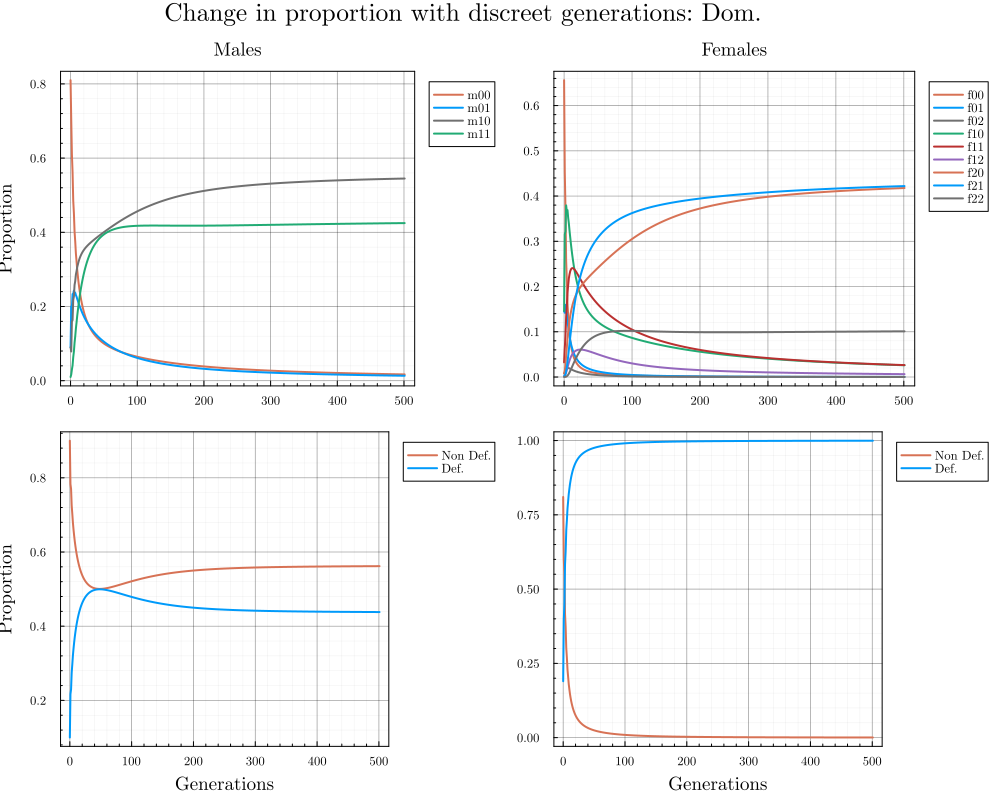

In [8]:
#Simulating proportions of each individual over a generation time
DOMINANT = true   #This simulation is for the recessive case
SHAPE = "linear"      #Shape for the survival function being used is exponential
gentime = 500

param = copy(P)    #Copying the main param dictionary to avoid making any changes to it
param["pm"] = 0.1
param["pf"] = 0.1

param["c_f"] = 0.5
param["c_m"] = 0.5

param["u"] = 0.1
param["r"] = 0.445

param["comb_f01"] = calc_combinations(param["B"], 2, 1, [0.5, 0.5])
param["comb_f11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [0.25, 0.25, 0.25, 0.25]) : calc_combinations(param["B"], 4, 2, [0.25, 0.25, 0.25, 0.25])
param["comb_f21"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [0.5, 0.5])
param["comb_f10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [0.5, 0.5]) : calc_combinations(param["B"], 2, 0, [0.5, 0.5]) 
param["comb_f12"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [0.5, 0.5]) : calc_combinations(param["B"], 2, 2, [0.5, 0.5]) 

param["comb_f00m00"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
param["comb_f00m01"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])

param["comb_f22m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])
param["comb_f22m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])


param["comb_f01m00"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
param["comb_f02m00"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
param["comb_f21m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
param["comb_f22m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

param["comb_f01m01"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
param["comb_f02m01"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
param["comb_f21m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
param["comb_f22m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

param["comb_f00m10"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
param["comb_f01m10"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
param["comb_f02m10"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
param["comb_f21m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])

param["comb_f00m11"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
param["comb_f01m11"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
param["comb_f02m11"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
param["comb_f21m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])


females = []
males = []

ind_prop = Dict(      #Dictionary storing the proportion of indivduals at each generation
    "m00" => [(1 - param["pf"])*(1 - param["pm"])],
    "m01" => [(1 - param["pf"])*(param["pm"])],
    "m10" => [(param["pf"])*(1 - param["pm"])],
    "m11" => [(param["pf"])*(param["pm"])],

    "f00" => [((1 - param["pf"])^2) * ((1 - param["pm"])^2)],
    "f01" => [((1 - param["pf"])^2) * (param["pm"] * (1 - param["pm"]) * 2)],
    "f02" => [((1 - param["pf"])^2) * ((param["pm"])^2)],

    "f10" => [(param["pf"] * (1 - param["pf"]) * 2) * ((1 - param["pm"])^2)],
    "f11" => [(param["pf"] * (1 - param["pf"]) * 2) * (param["pm"] * (1 - param["pm"]) * 2)],
    "f12" => [(param["pf"] * (1 - param["pf"]) * 2) * ((param["pm"])^2)],

    "f20" => [((param["pf"])^2) * ((1 - param["pm"])^2)],
    "f21" => [((param["pf"])^2) * (param["pm"] * (1 - param["pm"]) * 2)],
    "f22" => [((param["pf"])^2) * ((param["pm"])^2)]
)

for t in 0:gentime
    female_ls, male_ls = nexgen(param, females, males)

    push!(ind_prop["m00"], (male_ls[1] + male_ls[5]) / sum(male_ls))
    push!(ind_prop["m01"], (male_ls[2] + male_ls[6]) / sum(male_ls))
    push!(ind_prop["m10"], (male_ls[3] + male_ls[7]) / sum(male_ls))
    push!(ind_prop["m11"], (male_ls[4] + male_ls[8]) / sum(male_ls))

    push!(ind_prop["f00"], female_ls[1] / sum(female_ls))
    push!(ind_prop["f01"], female_ls[2] / sum(female_ls))
    push!(ind_prop["f02"], female_ls[3] / sum(female_ls))

    push!(ind_prop["f10"], female_ls[4] / sum(female_ls))
    push!(ind_prop["f11"], female_ls[5] / sum(female_ls))
    push!(ind_prop["f12"], female_ls[6] / sum(female_ls))

    push!(ind_prop["f20"], female_ls[7] / sum(female_ls))
    push!(ind_prop["f21"], female_ls[8] / sum(female_ls))
    push!(ind_prop["f22"], female_ls[9] / sum(female_ls))

    females = female_ls ./ sum(female_ls)
    males = male_ls ./ sum(male_ls)

    print("finished gen: ", t)
end


rng = collect(0:gentime+1)
p1 = plot(rng, [ind_prop["m00"] ind_prop["m01"] ind_prop["m10"] ind_prop["m11"]], labels = ["m00" "m01" "m10" "m11"], lw = 2, ylabel = "Proportion", title = "Males")
p2 = plot(rng, [ind_prop["f00"] ind_prop["f01"] ind_prop["f02"] ind_prop["f10"] ind_prop["f11"] ind_prop["f12"] ind_prop["f20"] ind_prop["f21"] ind_prop["f22"]], labels = ["f00" "f01" "f02" "f10" "f11" "f12" "f20" "f21" "f22"], lw = 2, title = "Females")
p3 = plot(rng, [(ind_prop["m00"] .+ ind_prop["m10"]) (ind_prop["m11"] .+ ind_prop["m01"])], labels = ["Non Def." "Def."], lw = 2, xlabel = "Generations", ylabel = "Proportion")
prec = plot(rng, [(ind_prop["f00"] .+ ind_prop["f01"] .+ ind_prop["f02"] .+ ind_prop["f10"] .+ ind_prop["f11"] .+ ind_prop["f12"]) (ind_prop["f20"] .+ ind_prop["f21"] .+ ind_prop["f22"])], labels = ["Non Def." "Def."], lw = 2, xlabel = "Generations")
pdom = plot(rng, [(ind_prop["f00"] .+ ind_prop["f01"] .+ ind_prop["f02"]) (ind_prop["f10"] .+ ind_prop["f11"] .+ ind_prop["f12"] .+ ind_prop["f20"] .+ ind_prop["f21"] .+ ind_prop["f22"])], labels = ["Non Def." "Def."], lw = 2, xlabel = "Generations")

plot(p1, p2, p3, DOMINANT ? pdom : prec, layout = (2,2), size = (1000,800), plot_title = string("Change in proportion with discreet generations: ", DOMINANT ? "Dom." : "Rec."))

#=The plots in order:
[[Proportion of all male genotypes; Proportion of all female genotypes]
 [Proportion of defenders in males; Proportion of defenders in females]]
=#

In [9]:
function prop_plot(P) #Function to produce dataframes of defender proportion with varying costs (c and alpha)
    range_cost = round.(collect(range(0, 1, 21)), digits = 2)#collect(0:1:20)
    #range_a = round.(collect(range(0, 1, 21)), digits = 2)

    param = copy(P)
    param["pm"] = 0.1
    param["pf"] = 0.1

    param["u"] = 0.05
    param["r"] = 0.3

    gentime = 650

    female_data = DataFrame([name => zeros(Float64, size(range_cost,1)) for name in string.(1:size(range_cost,1))])
    male_data = DataFrame([name => zeros(Float64, size(range_cost,1)) for name in string.(1:size(range_cost,1))])
    total_data = DataFrame([name => zeros(Float64, size(range_cost,1)) for name in string.(1:size(range_cost,1))])

    for i in 1:size(range_cost,1)

        param["c_f"] = range_cost[i]

        param["comb_f01"] = calc_combinations(param["B"], 2, 1, [0.5, 0.5])
        param["comb_f11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [0.25, 0.25, 0.25, 0.25]) : calc_combinations(param["B"], 4, 2, [0.25, 0.25, 0.25, 0.25])
        param["comb_f21"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [0.5, 0.5])
        param["comb_f10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [0.5, 0.5]) : calc_combinations(param["B"], 2, 0, [0.5, 0.5]) 
        param["comb_f12"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [0.5, 0.5]) : calc_combinations(param["B"], 2, 2, [0.5, 0.5]) 

        param["comb_f00m00"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
        param["comb_f00m01"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])

        param["comb_f22m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])
        param["comb_f22m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])

        param["comb_f01m00"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
        param["comb_f02m00"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
        param["comb_f21m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
        param["comb_f22m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

        param["comb_f01m01"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
        param["comb_f02m01"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
        param["comb_f21m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
        param["comb_f22m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

        param["comb_f00m10"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
        param["comb_f01m10"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
        param["comb_f02m10"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
        param["comb_f21m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])

        param["comb_f00m11"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
        param["comb_f01m11"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
        param["comb_f02m11"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
        param["comb_f21m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])


        for j in 1:size(range_cost,1)
            param["c_m"] = range_cost[j]

            females = []
            males = []
            
            female_ls = []
            male_ls = []
            for t in 0:gentime
                females, males = nexgen(param, female_ls, male_ls)

                female_ls = copy(females)
                male_ls = copy(males)

                female_ls = female_ls ./ (sum(female_ls))
                male_ls = male_ls ./ (sum(male_ls))
            end
                    
            if DOMINANT
                total_def = ((males[2] + males[6]) + (males[4] + males[8]) + sum(females[4:end])) / (sum(males) + sum(females))
                male_def = ((males[2] + males[6]) + (males[4] + males[8])) / sum(males)
                female_def = sum(females[4:end]) / sum(females)
            else
                total_def = ((males[2] + males[6]) + (males[4] + males[8]) + sum(females[7:end])) / (sum(males) + sum(females))
                male_def = ((males[2] + males[6]) + (males[4] + males[8])) / sum(males)
                female_def = sum(females[7:end]) / sum(females)
            end
            
            female_data[j,i] = female_def
            male_data[j,i] = male_def
            total_data[j,i] = total_def
        
        end
    
    end

    return female_data, male_data, total_data
end

prop_plot (generic function with 1 method)

In [17]:
shapes = ["s", "expinv", "linear", "exp"] #Running the function through all shapes and for both dominant and recessive cases, saving the output as csv
filepath = "C:/project/Masters_2023_DrHannaK/DataCSVs/multinomial/"

for i in 1:4
    SHAPE = shapes[i]
    DOMINANT = true
    f_dom, m_dom, t_dom = prop_plot(P)
    DOMINANT = false
    f_rec, m_rec, t_rec = prop_plot(P)

    CSV.write(string(filepath, "ML_f_dom_u05r3_", SHAPE,".csv"), f_dom)
    CSV.write(string(filepath, "ML_m_dom_u05r3_", SHAPE,".csv"), m_dom)
    CSV.write(string(filepath, "ML_t_dom_u05r3_", SHAPE,".csv"), t_dom)
    CSV.write(string(filepath, "ML_f_rec_u05r3_", SHAPE,".csv"), f_rec)
    CSV.write(string(filepath, "ML_m_rec_u05r3_", SHAPE,".csv"), m_rec)
    CSV.write(string(filepath, "ML_t_rec_u05r3_", SHAPE,".csv"), t_rec)
end

# Variation with increasing male population

In [10]:
function change_ur(P) #Function to change male population, and calculating the defender proportion alongside
    range_ur = round.(collect(range(0, 0.95, 20)), digits = 2)
    
    param = copy(P)
    param["pm"] = 0.1
    param["pf"] = 0.1

    param["c_f"] = 0.7
    param["c_m"] = 0.7

    gentime = 650

    female_data = DataFrame([name => zeros(Float64, size(range_ur,1)) for name in string.(1:size(range_ur,1))])
    male_data = DataFrame([name => zeros(Float64, size(range_ur,1)) for name in string.(1:size(range_ur,1))])
    total_data = DataFrame([name => zeros(Float64, size(range_ur,1)) for name in string.(1:size(range_ur,1))])

    for i in 1:size(range_ur,1)
        
        param["r"] = range_ur[i]

        param["comb_f01"] = calc_combinations(param["B"], 2, 1, [0.5, 0.5])
        param["comb_f11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [0.25, 0.25, 0.25, 0.25]) : calc_combinations(param["B"], 4, 2, [0.25, 0.25, 0.25, 0.25])
        param["comb_f21"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [0.5, 0.5])
        param["comb_f10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [0.5, 0.5]) : calc_combinations(param["B"], 2, 0, [0.5, 0.5]) 
        param["comb_f12"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [0.5, 0.5]) : calc_combinations(param["B"], 2, 2, [0.5, 0.5]) 

        param["comb_f00m00"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
        param["comb_f00m01"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])

        param["comb_f22m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])
        param["comb_f22m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])

        param["comb_f01m00"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
        param["comb_f02m00"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
        param["comb_f21m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
        param["comb_f22m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

        param["comb_f01m01"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
        param["comb_f02m01"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
        param["comb_f21m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
        param["comb_f22m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

        param["comb_f00m10"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
        param["comb_f01m10"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
        param["comb_f02m10"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
        param["comb_f21m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])

        param["comb_f00m11"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
        param["comb_f01m11"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
        param["comb_f02m11"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
        param["comb_f10m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
        param["comb_f11m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
        param["comb_f12m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
        param["comb_f20m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
        param["comb_f21m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])

        for j in 1:size(range_ur,1)
            param["u"] = range_ur[j]

            if i==0 && j==0
                female_data[i,j] = 0.0
                male_data[i,j] = 0.0
                total_data[i,j] = 0.0
                continue
            end

            females = []
            males = []
            
            female_ls = []
            male_ls = []
            for t in 0:gentime
                females, males = nexgen(param, female_ls, male_ls)

                female_ls = copy(females)
                male_ls = copy(males)

                female_ls = female_ls ./ (sum(female_ls))
                male_ls = male_ls ./ (sum(male_ls))
            end
                    
            if DOMINANT
                total_def = ((males[2] + males[6]) + (males[4] + males[8]) + sum(females[4:end])) / (sum(males) + sum(females))
                male_def = ((males[2] + males[6]) + (males[4] + males[8])) / sum(males)
                female_def = sum(females[4:end]) / sum(females)
            else
                total_def = ((males[2] + males[6]) + (males[4] + males[8]) + sum(females[7:end])) / (sum(males) + sum(females))
                male_def = ((males[2] + males[6]) + (males[4] + males[8])) / sum(males)
                female_def = sum(females[7:end]) / sum(females)
            end
                
            female_data[i,j] = female_def
            male_data[i,j] = male_def
            total_data[i,j] = total_def
        
        end
    
    end

    return female_data, male_data, total_data
end

change_ur (generic function with 1 method)

In [19]:
shapes = ["s", "exp", "expinv", "linear"] #Running the function through all shapes and for both dominant and recessive cases, saving the output as csv
filepath = "C:/project/Masters_2023_DrHannaK/DataCSVs/multinomial/ML_"

@showprogress 1 "Computing..." for i in 1:4
    SHAPE = shapes[i]  #shapes[i]
    DOMINANT = true
    f_dom, m_dom, t_dom = change_ur(P)
    DOMINANT = false
    f_rec, m_rec, t_rec = change_ur(P)

    CSV.write(string(filepath, "f_dom_", SHAPE,"_SR_cf7cf7",".csv"), f_dom)
    CSV.write(string(filepath, "m_dom_", SHAPE,"_SR_cf7cf7",".csv"), m_dom)
    CSV.write(string(filepath, "t_dom_", SHAPE,"_SR_cf7cf7",".csv"), t_dom)
    CSV.write(string(filepath, "f_rec_", SHAPE,"_SR_cf7cf7",".csv"), f_rec)
    CSV.write(string(filepath, "m_rec_", SHAPE,"_SR_cf7cf7",".csv"), m_rec)
    CSV.write(string(filepath, "t_rec_", SHAPE,"_SR_cf7cf7",".csv"), t_rec)
end

Computing... 100%|███████████████████████████████████████| Time: 0:14:08


In [17]:
#Simulating proportions of each individual over a generation time
DOMINANT = true    #Here we assume dominance
SHAPE = "linear"   #Shape used is exponential
gentime = 650

param = copy(P)    #Copying the main param dictionary to avoid making any changes to it
param["pm"] = 0.1
param["pf"] = 0.1

param["c_f"] = 0.7
param["c_m"] = 0.7

param["u"] = 0.85
param["r"] = 0.1

param["comb_f01"] = calc_combinations(param["B"], 2, 1, [0.5, 0.5])
param["comb_f11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [0.25, 0.25, 0.25, 0.25]) : calc_combinations(param["B"], 4, 2, [0.25, 0.25, 0.25, 0.25])
param["comb_f21"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [0.5, 0.5])
param["comb_f10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [0.5, 0.5]) : calc_combinations(param["B"], 2, 0, [0.5, 0.5]) 
param["comb_f12"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [0.5, 0.5]) : calc_combinations(param["B"], 2, 2, [0.5, 0.5]) 

param["comb_f00m00"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
param["comb_f00m01"] = calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])

param["comb_f22m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])
param["comb_f22m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]])


param["comb_f01m00"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
param["comb_f02m00"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
param["comb_f21m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
param["comb_f22m00"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

param["comb_f01m01"] = calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"])])
param["comb_f02m01"] = calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 0, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 2, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 2, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 0, [1-param["r"], param["r"]])
param["comb_f21m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 4, 1, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])
param["comb_f22m01"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 2, 2, [param["r"], 1-param["r"]]) : calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [param["r"], 1-param["r"]])

param["comb_f00m10"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
param["comb_f01m10"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
param["comb_f02m10"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m10"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
param["comb_f21m10"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])

param["comb_f00m11"] = DOMINANT ? calc_combinations(param["B"], 2, 1, [1-param["r"], param["r"]]) : calc_combinations(param["B"], 2, 0, [1-param["r"], param["r"]])
param["comb_f01m11"] = DOMINANT ? calc_combinations(param["B"], 4, 3, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [0.5 * param["r"], 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"]])
param["comb_f02m11"] = DOMINANT ? calc_combinations(param["B"], 2, 2, [param["r"], (1-param["r"])]) : calc_combinations(param["B"], 2, 1, [param["r"], (1-param["r"])])
param["comb_f10m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 2, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]]) : calc_combinations(param["B"], 4, 1, [ 0.5 * (1-param["r"]), 0.5 * (1-param["r"]), 0.5 * param["r"], 0.5 * param["r"]])
param["comb_f11m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 8, 6, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]]) : calc_combinations(param["B"], 8, 4, [ 0.25 * (param["r"]), 0.25 * (param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * (1-param["r"]), 0.25 * param["r"], 0.25 * param["r"]])
param["comb_f12m11"] = DOMINANT ? calc_combinations(int((1-param["c_f"])*param["B"]), 4, 4, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5]) : calc_combinations(param["B"], 4, 3, [param["r"] * 0.5, param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5])
param["comb_f20m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 2, 1, [1-param["r"], param["r"]])
param["comb_f21m11"] = calc_combinations(int((1-param["c_f"])*param["B"]), 4, 3, [param["r"] * 0.5, (1-param["r"]) * 0.5, (1-param["r"]) * 0.5, 0.5 * param["r"]])


females = []
males = []

female_ls = []
male_ls = []

for t in 0:gentime
    female_ls, male_ls = nexgen(param, females, males)

    females = female_ls ./ sum(female_ls)
    males = male_ls ./ sum(male_ls)
end


m_nd_nm = (male_ls[1] + male_ls[3]) / (sum(male_ls))
m_d_nm = (male_ls[2] + male_ls[4]) / (sum(male_ls))
m_nd_m = (male_ls[5] + male_ls[7]) / (sum(male_ls))
m_d_m = (male_ls[6] + male_ls[8]) / (sum(male_ls))

mixedsex = sum(male_ls[5:end]) / (sum(female_ls) + sum(male_ls))
singlesex = sum(male_ls[1:4]) / (sum(female_ls) + sum(male_ls))

p1 = bar(["Mixed Sex", "Single Sex"], [mixedsex, singlesex], ylims = (0,1), legend = false, ylabel = "Proportion")
#p2 = bar(["Mixed Sex", "Single Sex"], [m_d_m, m_d_nm], ylims = (0,1))

plot(p1, size = (500,500), dpi=1000)

print(mixedsex, "\n", singlesex)
#png(string("C:/project/Masters_2023_DrHannaK/outputs/","malepop_u84r84.png"))
#=The plots in order:
[[Proportion of all male genotypes; Proportion of all female genotypes]
 [Proportion of defenders in males; Proportion of defenders in females]]
=#
#print(((male_ls[2] + male_ls[6]) + (male_ls[4] + male_ls[8])) / sum(male_ls))

0.022172437109223484
0.7623455092953675